<a href="https://colab.research.google.com/github/SebaSRomanH/NBA/blob/main/nba2vec_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏀 NBA2Vec — Comparación de Embeddings (PCA · Autoencoder · Word2Vec)
**Fuente: `dataset_nba` desde Google Cloud Storage**

---

El dataset ya viene con una fila por **jugador × partido** con todas las features
aggregadas (promedios de temporada, ventanas L10/L20, tendencias, etc.).
No se recalcula historia: se usa directamente como perfil pre-partido.

| Sección | Descripción |
|---------|-------------|
| 1 | Configuración |
| 2 | Instalación e importación |
| 3 | Autenticación y carga desde GCS |
| 4 | Validación mínima |
| 5 | Selección de variables (control de fuga) |
| 6 | Perfil por jugador (agregación mínima) |
| 7 | Embedding PCA |
| 8 | Embedding Autoencoder |
| 9 | Embedding de Contexto (Word2Vec) |
| 10 | Jugadores similares |
| 11 | Visualizaciones comparativas |
| 12 | Clustering resumido |
| 13 | Comparación de métodos |
| 14 | Conclusiones |

> ⚠️ **No se entrenan modelos predictivos.** Análisis exclusivamente exploratorio.

---
## 1. Configuración

In [26]:
# =============================================================================
# CONFIGURACIÓN CENTRAL — editar antes de ejecutar
# =============================================================================

CONFIG = {
    # ── Google Cloud Storage ──────────────────────────────────────────────
    "GCS_BUCKET":      "nba-data",       # ← reemplazar
    "GCS_OBJECT_PATH": "dataset_nba.xlsx",    # ← reemplazar
    "FILE_FORMAT":     "xlsx",                     # xlsx | csv | parquet

    # ── Columnas del dataset ──────────────────────────────────────────────
    # Identidad
    "PLAYER_ID_COL":   "PLAYER_ID",
    "PLAYER_NAME_COL": "PLAYER_NAME",
    "GAME_ID_COL":     "TARGET_GAME_ID",
    "DATE_COL":        "TARGET_GAME_DATE",
    "TEAM_COL":        "TEAM_ABBREVIATION",
    "OPPONENT_COL":    "TARGET_OPP_TEAM_ABBREVIATION",
    "TARGET_COL":      "TARGET_FG3M",

    # ── Filtros ──────────────────────────────────────────────────────────
    # Mínimo de observaciones (filas) por jugador para incluirlo
    "MIN_ROWS_PER_PLAYER": 5, #son 5 partidos?

    # ── Embeddings ───────────────────────────────────────────────────────
    "PCA_COMPONENTS":        10,
    "AUTOENCODER_DIM":       10,
    "CONTEXT_EMBEDDING_DIM": 10,

    # ── Clustering ───────────────────────────────────────────────────────
    "N_CLUSTERS":   8,
    "RANDOM_STATE": 42,
}

# Parámetros Word2Vec (contexto)
CONTEXT_CONFIG = {
    "vector_size": CONFIG["CONTEXT_EMBEDDING_DIM"],
    "window":      5,
    "min_count":   2,
    "sg":          1,       # Skip-gram
    "negative":    10,
    "epochs":      100,
    "seed":        CONFIG["RANDOM_STATE"],
}

# URI completa
gcs_uri = f"gs://{CONFIG['GCS_BUCKET']}/{CONFIG['GCS_OBJECT_PATH']}"
print(f"   Configuración cargada")
print(f"   URI GCS: {gcs_uri}")
print(f"   Mín. filas por jugador: {CONFIG['MIN_ROWS_PER_PLAYER']}")

   Configuración cargada
   URI GCS: gs://nba-data/dataset_nba.xlsx
   Mín. filas por jugador: 5


---
## 2. Instalación e Importación

In [28]:
import subprocess, sys

def pip_install(pkg, import_name=None):
    name = import_name or pkg.split("[")[0]
    try:
        __import__(name)
    except ImportError:
        print(f"  Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"    {pkg} listo")

pip_install("gcsfs")
pip_install("openpyxl")
pip_install("pyarrow")
pip_install("gensim")
pip_install("tensorflow")

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.impute import SimpleImputer

import gensim
from gensim.models import Word2Vec

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

import gcsfs

# Semilla
np.random.seed(CONFIG["RANDOM_STATE"])
tf.random.set_seed(CONFIG["RANDOM_STATE"])

# Estilo visual oscuro (compatible con GitHub como PNG)
plt.style.use("dark_background")
BG  = "#1a1a2e"
TXT = "#EEEEEE"
ACC = "#4ECDC4"
PAL = ["#FF6B6B","#4ECDC4","#FFE66D","#A855F7","#14B8A6",
       "#F97316","#3B82F6","#EC4899","#84CC16","#06B6D4",
       "#F59E0B","#8B5CF6","#10B981","#EF4444","#6366F1"]
matplotlib.rcParams.update({
    "font.size":11, "axes.titlesize":13,
    "figure.facecolor": BG, "axes.facecolor": BG,
})

print(f" Librerías cargadas")
print(f" TensorFlow {tf.__version__} | gensim {gensim.__version__} | pandas {pd.__version__}")

✅ Librerías cargadas
   TensorFlow 2.20.0 | gensim 4.4.0 | pandas 2.2.2


---
## 3. Autenticación y Carga desde Google Cloud Storage

In [4]:
# Autenticación desde Google Colab
try:
    from google.colab import auth
    auth.authenticate_user()
    print(" Autenticado en Google Colab")
except ImportError:
    print("  Entorno no-Colab — se asume autenticación previa (gcloud / ADC)")

✅ Autenticado en Google Colab


In [5]:
def load_from_gcs(bucket: str, object_path: str, file_format: str) -> pd.DataFrame:
    """
    Carga dataset_nba desde Google Cloud Storage.

    Formatos soportados: xlsx, csv, parquet.

    Errores capturados con mensajes claros:
    - Bucket o ruta inexistente
    - Sin permisos (403 / PermissionError)
    - Formato no soportado
    """
    uri = f"gs://{bucket}/{object_path}"
    fmt = file_format.lower().strip(".")

    if fmt not in {"xlsx", "csv", "parquet"}:
        raise ValueError(
            f"Formato '{fmt}' no soportado.\n"
            f"Cambia CONFIG['FILE_FORMAT'] a: xlsx, csv o parquet."
        )

    print(f"📂 Conectando a: {uri}")
    try:
        fs = gcsfs.GCSFileSystem()

        if fmt == "xlsx":
            with fs.open(uri, "rb") as f:
                df = pd.read_excel(f, engine="openpyxl")
        elif fmt == "csv":
            with fs.open(uri, "rt", encoding="utf-8") as f:
                df = pd.read_csv(f)
        elif fmt == "parquet":
            with fs.open(uri, "rb") as f:
                df = pd.read_parquet(f)

        print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]:,} columnas")
        return df

    except FileNotFoundError:
        raise FileNotFoundError(
            f"❌ No se encontró: {uri}\n"
            f"   → Verifica GCS_BUCKET y GCS_OBJECT_PATH en CONFIG."
        )
    except PermissionError:
        raise PermissionError(
            f"❌ Sin permisos para acceder a: {uri}\n"
            f"   → Verifica que tu cuenta tenga roles/storage.objectViewer en el bucket."
        )
    except Exception as e:
        msg = str(e).lower()
        if any(k in msg for k in ["not found", "no such", "404"]):
            raise FileNotFoundError(
                f"❌ Objeto no encontrado: {uri}\n   Detalle: {e}"
            )
        elif any(k in msg for k in ["permission", "403", "forbidden", "access"]):
            raise PermissionError(
                f"❌ Acceso denegado: {uri}\n   Detalle: {e}"
            )
        else:
            raise RuntimeError(
                f"❌ Error inesperado al cargar desde GCS.\n   Detalle: {e}"
            )


# ── Cargar ────────────────────────────────────────────────────────────────────
df_raw = load_from_gcs(
    CONFIG["GCS_BUCKET"],
    CONFIG["GCS_OBJECT_PATH"],
    CONFIG["FILE_FORMAT"]
)

📂 Conectando a: gs://nba-data/dataset_nba.xlsx
✅ Dataset cargado: 3,122 filas × 419 columnas


---
## 4. Validación Mínima

Verifica columnas clave e imprime un resumen compacto del dataset.

In [6]:
def resolve_col(df, candidates, label):
    """Devuelve la primera columna disponible de la lista; avisa si usa alternativa."""
    for c in candidates:
        if c in df.columns:
            if c != candidates[0]:
                print(f"   ⚠️  '{label}': usando '{c}' en lugar de '{candidates[0]}'")
            return c
    print(f"   ⚠️  '{label}': ninguna columna encontrada {candidates}")
    return None


# Resolver columnas con alternativas razonables
COL = {
    "player_id":   resolve_col(df_raw,
        [CONFIG["PLAYER_ID_COL"],   "PLAYER_ID"],
        "PLAYER_ID"),
    "player_name": resolve_col(df_raw,
        [CONFIG["PLAYER_NAME_COL"], "PLAYER_NAME", "PLAYER", "PLAYER_FULL_NAME"],
        "PLAYER_NAME"),
    "game_id":     resolve_col(df_raw,
        [CONFIG["GAME_ID_COL"],     "TARGET_GAME_ID", "GAME_ID"],
        "GAME_ID"),
    "date":        resolve_col(df_raw,
        [CONFIG["DATE_COL"],        "TARGET_GAME_DATE", "GAME_DATE", "DATE"],
        "DATE"),
    "team":        resolve_col(df_raw,
        [CONFIG["TEAM_COL"],        "TEAM_ABBREVIATION", "TEAM",
         "TARGET_TEAM_ABBREVIATION"],
        "TEAM"),
    "opponent":    resolve_col(df_raw,
        [CONFIG["OPPONENT_COL"],    "TARGET_OPP_TEAM_ABBREVIATION",
         "OPP_TEAM_ABBREVIATION"],
        "OPPONENT"),
}

# ── Resumen ───────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  VALIDACIÓN MÍNIMA — dataset_nba")
print("="*60)
print(f"  Filas totales:   {df_raw.shape[0]:>10,}")
print(f"  Columnas totales:{df_raw.shape[1]:>10,}")

id_c = COL["player_id"] or COL["player_name"]
if id_c:
    print(f"  Jugadores únicos:{df_raw[id_c].nunique():>10,}")

game_c = COL["game_id"]
if game_c:
    print(f"  Partidos únicos: {df_raw[game_c].nunique():>10,}")

date_c = COL["date"]
if date_c:
    try:
        dates = pd.to_datetime(df_raw[date_c], errors="coerce")
        print(f"  Rango fechas:    {dates.min().date()} → {dates.max().date()}")
    except Exception:
        pass

null_pct = 100 * df_raw.isnull().sum().sum() / (df_raw.shape[0] * df_raw.shape[1])
print(f"  Nulos globales:  {null_pct:>9.1f}%")
print(f"  Columnas ID:     {COL}")
print("="*60)
print()
print("Nota: el dataset ya tiene features agregadas por partido.")
print("No se recalculará historia; se usará directamente como perfil pre-partido.")


  VALIDACIÓN MÍNIMA — dataset_nba
  Filas totales:        3,122
  Columnas totales:       419
  Jugadores únicos:       452
  Partidos únicos:        155
  Rango fechas:    2026-02-03 → 2026-03-01
  Nulos globales:        5.3%
  Columnas ID:     {'player_id': 'PLAYER_ID', 'player_name': 'PLAYER_NAME', 'game_id': 'TARGET_GAME_ID', 'date': 'TARGET_GAME_DATE', 'team': 'TEAM_ABBREVIATION', 'opponent': 'TARGET_OPP_TEAM_ABBREVIATION'}

Nota: el dataset ya tiene features agregadas por partido.
No se recalculará historia; se usará directamente como perfil pre-partido.


---
## 5. Selección de Variables — Control de Fuga de Información

Exclusiones aplicadas:
- `TARGET_*` y `NEXT_GAME_*` → contienen resultados del partido objetivo
- Columnas identificadoras → solo se usan como llaves, no como features
- Alias legacy (`GAME_DATE`, `NEXT_GAME_DATE`, `NEXT_OPP_TEAM_ABBREVIATION`, `TEAM_ABBREVIATION`)
- Tipo `object` / texto
- Columnas constantes o con exceso de nulos (> 60 %)

In [7]:
def select_features(df: pd.DataFrame, col_map: dict,
                    max_null_pct: float = 0.60) -> tuple:
    """
    Selecciona variables numéricas válidas para embeddings.
    Retorna (feature_cols, audit_df).
    """
    # Conjunto de columnas a tratar como identificadoras / contexto
    id_cols = set(filter(None, col_map.values())) | {
        # Alias legacy documentados en la especificación funcional
        "TEAM_ABBREVIATION", "GAME_DATE",
        "NEXT_GAME_DATE", "NEXT_OPP_TEAM_ABBREVIATION",
        "PLAYER_NAME_RAW", "TARGET_MATCHUP",
        "TARGET_TEAM_ID", "TARGET_TEAM_NAME",
        "LAST_GAME_ID", "LAST_GAME_TEAM_ABBREVIATION",
        "LAST_GAME_OPP_TEAM_ABBREVIATION", "LAST_GAME_DATE",
        "LAST_GAME_TEAM_ABBREVIATION",
        "OPP_TEAM_ID", "OPP_TEAM_NAME",
        "OPP_TEAM_LAST_GAME_DATE",
        "OPP_TEAM_LAST_GAME_OPP_ABBREVIATION",
        "OPP_TEAM_FEATURES_CREATED_UTC",
    }

    records = []
    for col in df.columns:
        null_p = df[col].isnull().mean()

        if col.startswith("TARGET_"):
            action, reason = "EXCLUDE", "Fuga: TARGET_* (resultado del partido)"
        elif col.startswith("NEXT_GAME_"):
            action, reason = "EXCLUDE", "Fuga: NEXT_GAME_* (alias legacy de target)"
        elif col in id_cols:
            action, reason = "EXCLUDE", "Identificador / contexto / legacy"
        elif df[col].dtype == object:
            action, reason = "EXCLUDE", "Tipo texto (object)"
        elif null_p > max_null_pct:
            action, reason = "EXCLUDE", f"Nulos: {null_p:.0%} > {max_null_pct:.0%}"
        elif df[col].nunique() <= 1:
            action, reason = "EXCLUDE", "Columna constante"
        else:
            action, reason = "INCLUDE", "—"

        records.append({"COLUMN": col, "ACTION": action, "REASON": reason})

    audit = pd.DataFrame(records)
    feature_cols = audit.loc[audit["ACTION"] == "INCLUDE", "COLUMN"].tolist()

    n_inc = (audit["ACTION"] == "INCLUDE").sum()
    n_exc = (audit["ACTION"] == "EXCLUDE").sum()

    print(f"\n📋 AUDITORÍA DE VARIABLES")
    print(f"   Total columnas: {len(audit)} | INCLUDE: {n_inc} | EXCLUDE: {n_exc}")
    print("\n  Columnas excluidas (primeras 25):")
    print(audit[audit["ACTION"]=="EXCLUDE"][["COLUMN","REASON"]].head(25).to_string(index=False))
    print(f"\n  Variables seleccionadas para embeddings: {n_inc}")
    return feature_cols, audit


FEATURE_COLS, audit_df = select_features(df_raw, COL)


📋 AUDITORÍA DE VARIABLES
   Total columnas: 419 | INCLUDE: 166 | EXCLUDE: 253

  Columnas excluidas (primeras 25):
                         COLUMN                                     REASON
                      PLAYER_ID          Identificador / contexto / legacy
                    PLAYER_NAME          Identificador / contexto / legacy
                PLAYER_NAME_RAW          Identificador / contexto / legacy
                 TARGET_GAME_ID     Fuga: TARGET_* (resultado del partido)
               TARGET_GAME_DATE     Fuga: TARGET_* (resultado del partido)
             TARGET_SEASON_YEAR     Fuga: TARGET_* (resultado del partido)
             TARGET_SEASON_TYPE     Fuga: TARGET_* (resultado del partido)
                 TARGET_TEAM_ID     Fuga: TARGET_* (resultado del partido)
       TARGET_TEAM_ABBREVIATION     Fuga: TARGET_* (resultado del partido)
               TARGET_TEAM_NAME     Fuga: TARGET_* (resultado del partido)
                 TARGET_MATCHUP     Fuga: TARGET_* (resulta

---
## 6. Perfil por Jugador (Agregación Mínima)

El dataset ya viene con features agregadas (promedios de temporada, ventanas L10/L20, tendencias, etc.).
La única transformación necesaria es **colapsar múltiples filas por jugador en una sola**,
calculando la media de cada variable numérica a través de sus partidos.

Esto garantiza que el embedding represente el perfil "típico" del jugador en el período disponible,
sin recalcular historia desde el historial crudo.

In [8]:
def build_player_profiles(df: pd.DataFrame,
                          feature_cols: list,
                          col_map: dict,
                          min_rows: int) -> pd.DataFrame:
    """
    Colapsa múltiples filas por jugador calculando la media de cada feature.

    La columna de agrupación es PLAYER_ID (o PLAYER_NAME si no existe).
    Se excluyen jugadores con menos de `min_rows` filas.

    El perfil resultante refleja el estado promedio del jugador a lo largo
    de sus partidos disponibles, usando exclusivamente variables pre-partido.
    """
    id_col   = col_map.get("player_id") or col_map.get("player_name")
    name_col = col_map.get("player_name")
    team_col = col_map.get("team")

    if id_col is None:
        raise ValueError("No se encontró columna identificadora de jugador")

    # Solo columnas numéricas que existan en el dataset
    num_cols = [c for c in feature_cols
                if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]

    print(f"   Variables numéricas disponibles: {len(num_cols)}")

    # Filtrar jugadores con pocas filas
    counts = df.groupby(id_col).size().rename("n_filas")
    valid  = counts[counts >= min_rows].index
    excl   = len(counts) - len(valid)
    df_f   = df[df[id_col].isin(valid)].copy()

    print(f"   Jugadores antes del filtro:  {len(counts)}")
    print(f"   Excluidos (< {min_rows} filas):     {excl}")
    print(f"   Jugadores incluidos:         {len(valid)}")

    # Agregar: media de cada variable por jugador
    profiles = df_f.groupby(id_col)[num_cols].mean()
    profiles = profiles.join(counts).reset_index()

    # Añadir nombre si es distinto al ID
    if name_col and name_col in df.columns and name_col != id_col:
        name_map = df.groupby(id_col)[name_col].first()
        profiles = profiles.merge(name_map, on=id_col, how="left")

    # Equipo más frecuente (informativo, no predictivo)
    if team_col and team_col in df.columns:
        team_map = df.groupby(id_col)[team_col].agg(lambda x: x.mode().iloc[0])
        profiles = profiles.merge(team_map, on=id_col, how="left")

    print(f"\n✅ Perfil construido: {profiles.shape[0]} jugadores × {profiles.shape[1]} columnas")
    return profiles


player_profiles_df = build_player_profiles(
    df_raw, FEATURE_COLS, COL, CONFIG["MIN_ROWS_PER_PLAYER"]
)
player_profiles_df.head(3)

   Variables numéricas disponibles: 166
   Jugadores antes del filtro:  452
   Excluidos (< 5 filas):     124
   Jugadores incluidos:         328

✅ Perfil construido: 328 jugadores × 170 columnas


,PLAYER_ID,AGE,WEIGHT,GAMES_PLAYED,GAMES_PLAYED_L10,GAMES_PLAYED_L20,DAYS_SINCE_LAST_GAME,LAST_GAME_PTS,LAST_GAME_AST,LAST_GAME_REB,...,MIN_PF_L20,PFD_TOTAL_L20,MAX_PFD_L20,MIN_PFD_L20,PTS_TOTAL_L20,MAX_PTS_L20,MIN_PTS_L20,n_filas,PLAYER_NAME,TEAM_ABBREVIATION
0,2544,41.0,250.0,36.5,10.0,20.0,2.600,20.30,8.300,5.600,...,0.0,73.900,7.0,1.0,442.30,30.80,11.0,10,LeBron James,LAL
1,201142,37.0,240.0,50.5,10.0,20.0,2.400,25.70,4.200,5.400,...,0.0,88.300,8.0,0.0,524.80,39.10,13.0,10,Kevin Durant,HOU
2,201143,39.0,240.0,33.5,10.0,20.0,3.125,10.75,3.375,4.625,...,0.0,8.875,2.0,0.0,172.75,16.75,3.0,8,Al Horford,GSW


---
## Preparación Común de la Matriz

La misma matriz escalada `X_player_scaled` alimenta PCA y Autoencoder, garantizando comparabilidad.

In [9]:
def prepare_matrix(profiles: pd.DataFrame, id_col: str,
                   name_col: str, team_col: str) -> tuple:
    """
    A partir del perfil por jugador, construye la matriz numérica escalada:
    1. Excluye columnas no numéricas y auxiliares (ID, nombre, equipo, n_filas)
    2. Reemplaza infinitos
    3. Imputa nulos con mediana
    4. Elimina columnas con varianza cero
    5. Elimina colinealidad extrema (|r| > 0.97)
    6. StandardScaler

    Retorna (X_scaled, feature_names, scaler)
    """
    exclude = set(filter(None, [id_col, name_col, team_col, "n_filas"]))
    num_cols = [
        c for c in profiles.columns
        if c not in exclude
        and pd.api.types.is_numeric_dtype(profiles[c])
    ]

    X = profiles[num_cols].copy()
    X.replace([np.inf, -np.inf], np.nan, inplace=True)

    imp = SimpleImputer(strategy="median")
    X_imp = pd.DataFrame(imp.fit_transform(X), columns=num_cols)

    # Eliminar constantes
    var_mask = X_imp.var() > 1e-8
    dropped_const = (~var_mask).sum()
    X_imp = X_imp.loc[:, var_mask]
    if dropped_const:
        print(f"   Eliminadas {dropped_const} columnas constantes")

    # Eliminar colinealidad extrema (|r| > 0.97)
    corr = X_imp.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_corr = [c for c in upper.columns if (upper[c] > 0.97).any()]
    X_imp.drop(columns=drop_corr, inplace=True)
    if drop_corr:
        print(f"   Eliminadas {len(drop_corr)} columnas por alta colinealidad (|r|>0.97)")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imp)

    print(f"   ✅ Matriz final: {X_scaled.shape[0]} jugadores × {X_scaled.shape[1]} variables")
    return X_scaled, X_imp.columns.tolist(), scaler


ID_COL   = COL.get("player_id") or COL.get("player_name")
NAME_COL = COL.get("player_name") or ID_COL
TEAM_COL = COL.get("team")

X_player_scaled, feature_names, base_scaler = prepare_matrix(
    player_profiles_df, ID_COL, NAME_COL, TEAM_COL
)

   Eliminadas 4 columnas constantes
   Eliminadas 17 columnas por alta colinealidad (|r|>0.97)
   ✅ Matriz final: 328 jugadores × 145 variables


---
## 7. Embedding PCA

**Flujo:** `dataset_nba` (perfil pre-partido ya agregado) → escalamiento → PCA → embedding

In [10]:
# Ajuste automático de componentes
n_comp = min(CONFIG["PCA_COMPONENTS"],
             X_player_scaled.shape[1],
             X_player_scaled.shape[0] - 1)

print(f"Jugadores: {X_player_scaled.shape[0]} | Variables: {X_player_scaled.shape[1]} | Componentes PCA: {n_comp}")

pca_model = PCA(n_components=n_comp, random_state=CONFIG["RANDOM_STATE"])
X_pca     = pca_model.fit_transform(X_player_scaled)

var_exp = pca_model.explained_variance_ratio_
cum_var = np.cumsum(var_exp)

# DataFrame de embeddings PCA
pca_emb = {f"PCA_VEC_{i+1:02d}": X_pca[:, i] for i in range(n_comp)}
pca_embeddings_df = pd.DataFrame(pca_emb)
for col in [ID_COL, NAME_COL, TEAM_COL]:
    if col and col in player_profiles_df.columns:
        pca_embeddings_df[col] = player_profiles_df[col].values

print(f"\n✅ pca_embeddings_df: {pca_embeddings_df.shape}")
print(f"   Varianza acumulada ({n_comp} comp): {cum_var[-1]:.1%}")
pca_embeddings_df.head(3)

Jugadores: 328 | Variables: 145 | Componentes PCA: 10

✅ pca_embeddings_df: (328, 13)
   Varianza acumulada (10 comp): 73.6%


,PCA_VEC_01,PCA_VEC_02,PCA_VEC_03,PCA_VEC_04,PCA_VEC_05,PCA_VEC_06,PCA_VEC_07,PCA_VEC_08,PCA_VEC_09,PCA_VEC_10,PLAYER_ID,PLAYER_NAME,TEAM_ABBREVIATION
0,11.811245,-2.322432,-5.533316,0.004947,-3.075541,-5.619653,1.668969,-0.941543,3.389971,0.102809,2544,LeBron James,LAL
1,14.456575,-3.320774,1.037160,-0.153536,-0.788058,-0.646412,0.731970,2.021053,3.394564,-1.718275,201142,Kevin Durant,HOU
2,-2.434546,0.362561,2.243125,-1.390503,1.874686,-2.345637,2.651616,0.245520,2.211291,-1.011065,201143,Al Horford,GSW


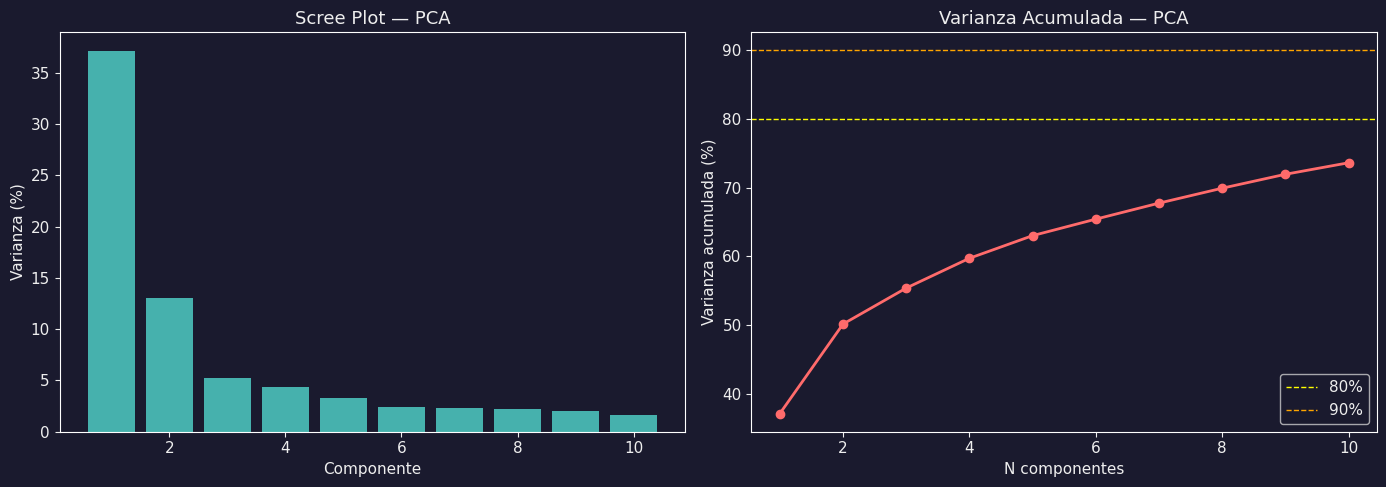

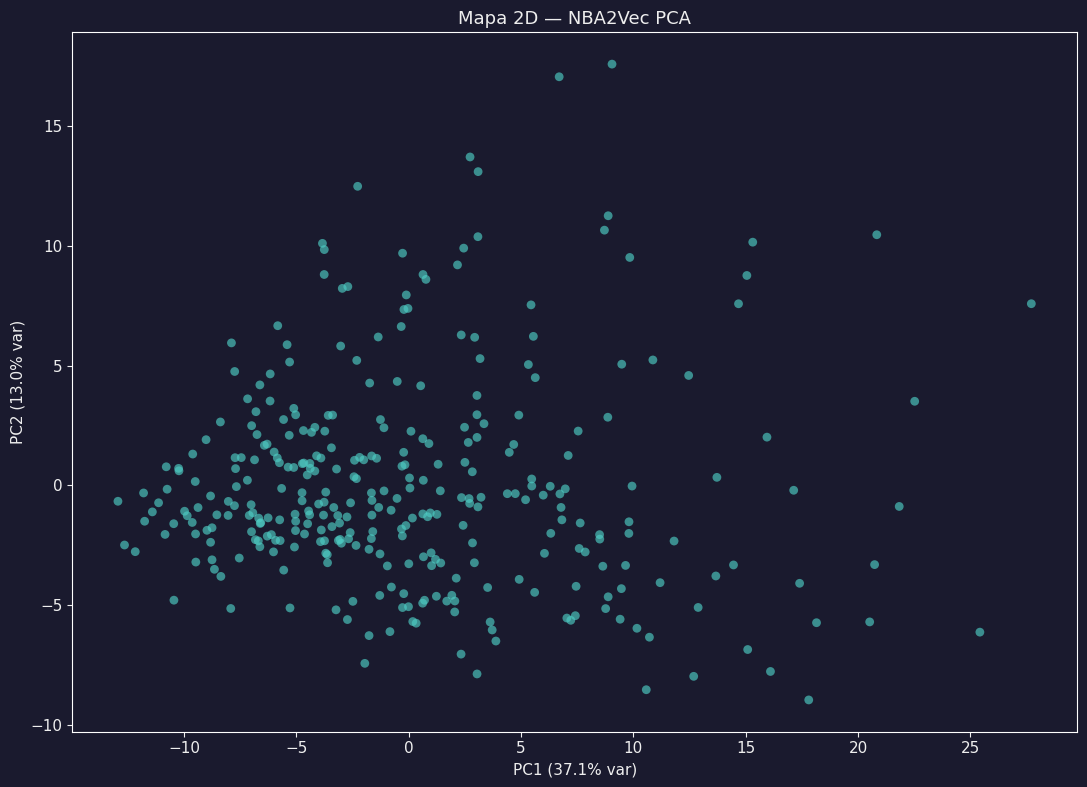

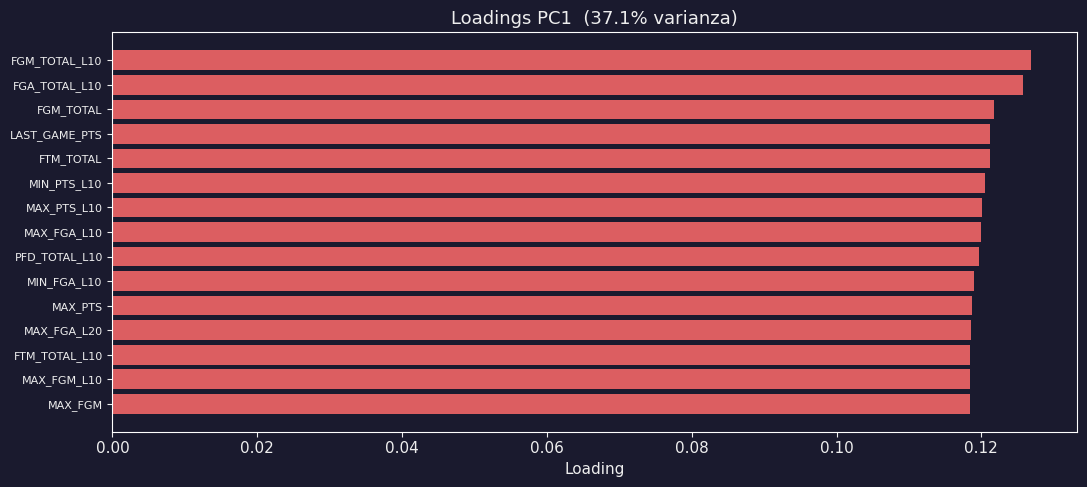

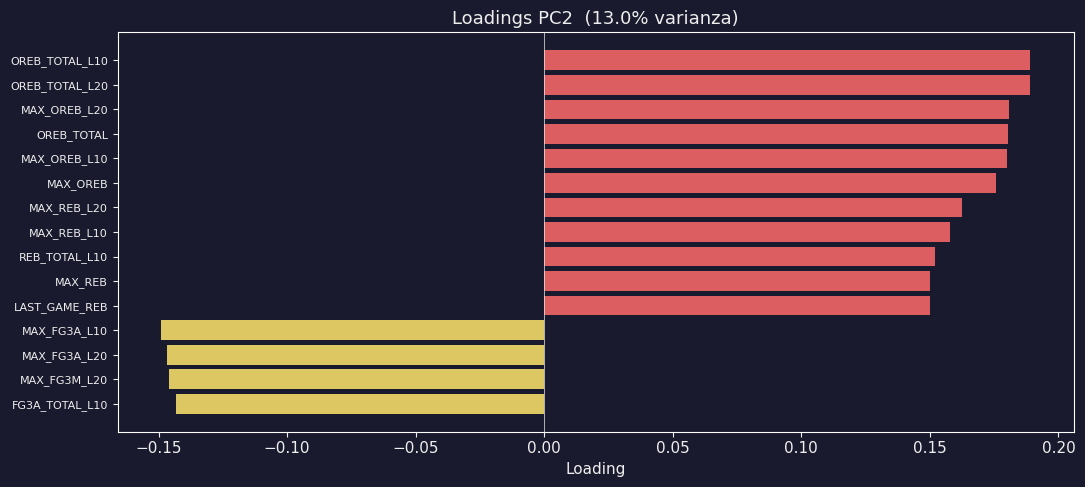


📐 Interpretación PCA
   PC1 (37.1%): variables dominantes → ['FGM_TOTAL_L10', 'FGA_TOTAL_L10', 'FGM_TOTAL']
   PC2 (13.0%): variables dominantes → ['OREB_TOTAL_L10', 'OREB_TOTAL_L20', 'MAX_OREB_L20']
   Varianza acumulada total: 73.6%
   (Interpretar según las variables reales del dataset)


In [11]:
# ── Gráfico 1: Scree plot + Varianza acumulada ───────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
x = range(1, n_comp + 1)

ax1.bar(x, var_exp * 100, color=ACC, alpha=0.85)
ax1.set_xlabel("Componente", color=TXT); ax1.set_ylabel("Varianza (%)", color=TXT)
ax1.set_title("Scree Plot — PCA", color=TXT); ax1.tick_params(colors=TXT)

ax2.plot(x, cum_var * 100, marker="o", color=PAL[0], lw=2)
ax2.axhline(80, color="yellow", ls="--", lw=1, label="80%")
ax2.axhline(90, color="orange", ls="--", lw=1, label="90%")
ax2.set_xlabel("N componentes", color=TXT); ax2.set_ylabel("Varianza acumulada (%)", color=TXT)
ax2.set_title("Varianza Acumulada — PCA", color=TXT)
ax2.legend(facecolor=BG, labelcolor=TXT); ax2.tick_params(colors=TXT)

plt.tight_layout()
plt.savefig("pca_scree.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Gráfico 2: Mapa 2D PC1 vs PC2 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8), facecolor=BG)
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=ACC, s=40, alpha=0.65, edgecolors="none")
ax.set_xlabel(f"PC1 ({var_exp[0]:.1%} var)", color=TXT)
ax.set_ylabel(f"PC2 ({var_exp[1]:.1%} var)" if n_comp > 1 else "PC2", color=TXT)
ax.set_title("Mapa 2D — NBA2Vec PCA", color=TXT); ax.tick_params(colors=TXT)
plt.tight_layout()
plt.savefig("pca_map2d.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Gráfico 3: Loadings PC1 y PC2 ─────────────────────────────────────────────
n_top = min(15, len(feature_names))
for pc_i, pc_label in [(0, "PC1"), (1, "PC2")]:
    if pc_i >= n_comp:
        continue
    loadings  = pca_model.components_[pc_i]
    top_idx   = np.argsort(np.abs(loadings))[::-1][:n_top]
    top_vals  = loadings[top_idx]
    top_names = [feature_names[i] for i in top_idx]

    fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
    colors_b = [PAL[0] if v >= 0 else PAL[2] for v in top_vals]
    ax.barh(range(n_top), top_vals[::-1], color=colors_b[::-1], alpha=0.85)
    ax.set_yticks(range(n_top))
    ax.set_yticklabels(top_names[::-1], color=TXT, fontsize=8)
    ax.axvline(0, color=TXT, lw=0.5)
    ax.set_xlabel("Loading", color=TXT)
    ax.set_title(f"Loadings {pc_label}  ({var_exp[pc_i]:.1%} varianza)", color=TXT)
    ax.tick_params(colors=TXT)
    plt.tight_layout()
    plt.savefig(f"pca_loadings_{pc_label}.png", dpi=120, bbox_inches="tight")
    plt.show()

# ── Interpretación breve ──────────────────────────────────────────────────────
pc1_top3 = [feature_names[i] for i in np.argsort(np.abs(pca_model.components_[0]))[::-1][:3]]
print(f"\n📐 Interpretación PCA")
print(f"   PC1 ({var_exp[0]:.1%}): variables dominantes → {pc1_top3}")
if n_comp > 1:
    pc2_top3 = [feature_names[i] for i in np.argsort(np.abs(pca_model.components_[1]))[::-1][:3]]
    print(f"   PC2 ({var_exp[1]:.1%}): variables dominantes → {pc2_top3}")
print(f"   Varianza acumulada total: {cum_var[-1]:.1%}")
print("   (Interpretar según las variables reales del dataset)")

---
## 8. Embedding Autoencoder

Usa la **misma** `X_player_scaled` que PCA.

Arquitectura: `entrada → 64 → 32 → embedding → 32 → 64 → reconstrucción`

In [12]:
def build_autoencoder(input_dim: int, emb_dim: int, seed: int):
    """
    Construye autoencoder simétrico.
    Adapta capas intermedias si input_dim es pequeño.
    Retorna (autoencoder, encoder, emb_dim_efectivo)
    """
    tf.random.set_seed(seed)
    np.random.seed(seed)

    h1      = min(64, max(input_dim * 2, 16))
    h2      = min(32, max(h1 // 2, 8))
    emb_eff = min(emb_dim, h2)

    inp = keras.Input(shape=(input_dim,), name="input")
    x   = layers.Dense(h1, activation="relu", name="enc1")(inp)
    x   = layers.Dense(h2, activation="relu", name="enc2")(x)
    emb = layers.Dense(emb_eff, activation="linear", name="embedding")(x)
    x   = layers.Dense(h2, activation="relu", name="dec1")(emb)
    x   = layers.Dense(h1, activation="relu", name="dec2")(x)
    out = layers.Dense(input_dim, activation="linear", name="output")(x)

    autoencoder = keras.Model(inp, out, name="autoencoder")
    encoder     = keras.Model(inp, emb, name="encoder")
    autoencoder.compile(optimizer="adam", loss="mse")

    print(f"   Arq: {input_dim}→{h1}→{h2}→{emb_eff}→{h2}→{h1}→{input_dim}")
    return autoencoder, encoder, emb_eff


autoencoder, encoder, AE_DIM = build_autoencoder(
    X_player_scaled.shape[1],
    CONFIG["AUTOENCODER_DIM"],
    CONFIG["RANDOM_STATE"]
)
autoencoder.summary()

   Arq: 145→64→32→10→32→64→145


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 145)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc1 (Dense)                    │ (None, 64)             │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc2 (Dense)                    │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec1 (Dense)                    │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec2 (Dense)                    │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 145)            │         9,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,643 (92.36 KB)

 Trainable params: 23,643 (92.36 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=10,
    restore_best_weights=True, verbose=0
)

history = autoencoder.fit(
    X_player_scaled, X_player_scaled,
    epochs=300,
    batch_size=min(32, max(8, len(X_player_scaled) // 4)),
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=0
)

final_epoch = len(history.history["loss"])
train_loss  = history.history["loss"][-1]
val_loss    = history.history["val_loss"][-1]

X_ae    = encoder.predict(X_player_scaled, verbose=0)
X_recon = autoencoder.predict(X_player_scaled, verbose=0)
recon_errors = np.mean((X_player_scaled - X_recon) ** 2, axis=1)
mean_error   = recon_errors.mean()

print(f"\n✅ Autoencoder entrenado")
print(f"   Épocas:                  {final_epoch}")
print(f"   Loss entrenamiento:      {train_loss:.6f}")
print(f"   Loss validación:         {val_loss:.6f}")
print(f"   Error medio reconstrucción: {mean_error:.6f}")
print(f"   Dimensión embedding:     {AE_DIM}")
print()
print("📋 Interpretación: dos jugadores cercanos en este espacio aprendieron")
print("   patrones estadísticos similares de forma no lineal.")
print("   La proximidad NO implica que el autoencoder los declaró equivalentes;")
print("   significa que sus perfiles se reconstruyen desde representaciones similares.")

# DataFrame de embeddings autoencoder
ae_emb_cols = {f"AE_VEC_{i+1:02d}": X_ae[:, i] for i in range(AE_DIM)}
autoencoder_embeddings_df = pd.DataFrame(ae_emb_cols)
for col in [ID_COL, NAME_COL, TEAM_COL]:
    if col and col in player_profiles_df.columns:
        autoencoder_embeddings_df[col] = player_profiles_df[col].values

print(f"\n✅ autoencoder_embeddings_df: {autoencoder_embeddings_df.shape}")
autoencoder_embeddings_df.head(3)


✅ Autoencoder entrenado
   Épocas:                  132
   Loss entrenamiento:      0.165288
   Loss validación:         0.218162
   Error medio reconstrucción: 0.175311
   Dimensión embedding:     10

📋 Interpretación: dos jugadores cercanos en este espacio aprendieron
   patrones estadísticos similares de forma no lineal.
   La proximidad NO implica que el autoencoder los declaró equivalentes;
   significa que sus perfiles se reconstruyen desde representaciones similares.

✅ autoencoder_embeddings_df: (328, 13)


,AE_VEC_01,AE_VEC_02,AE_VEC_03,AE_VEC_04,AE_VEC_05,AE_VEC_06,AE_VEC_07,AE_VEC_08,AE_VEC_09,AE_VEC_10,PLAYER_ID,PLAYER_NAME,TEAM_ABBREVIATION
0,-9.908946,-5.439507,-12.069136,1.949000,5.192332,-5.860662,-5.161125,3.868376,2.316899,-4.899619,2544,LeBron James,LAL
1,-8.354244,-1.110860,-9.079486,3.892040,11.271091,-4.890383,-8.402652,-0.063851,1.783311,-3.794154,201142,Kevin Durant,HOU
2,-0.588878,1.177437,-1.419290,-0.928763,1.648212,-1.366677,-6.267483,1.385406,-2.796018,-1.493945,201143,Al Horford,GSW


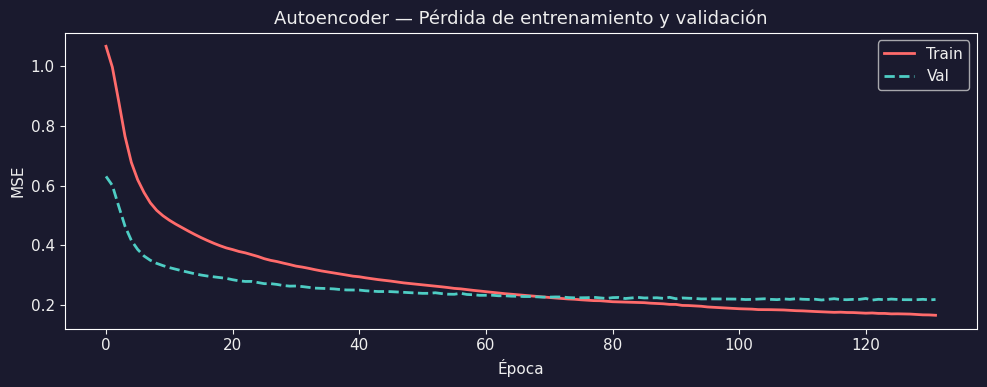

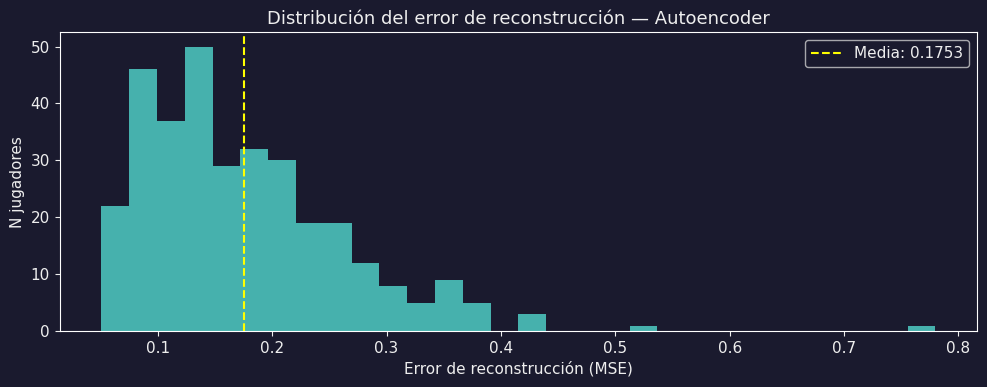

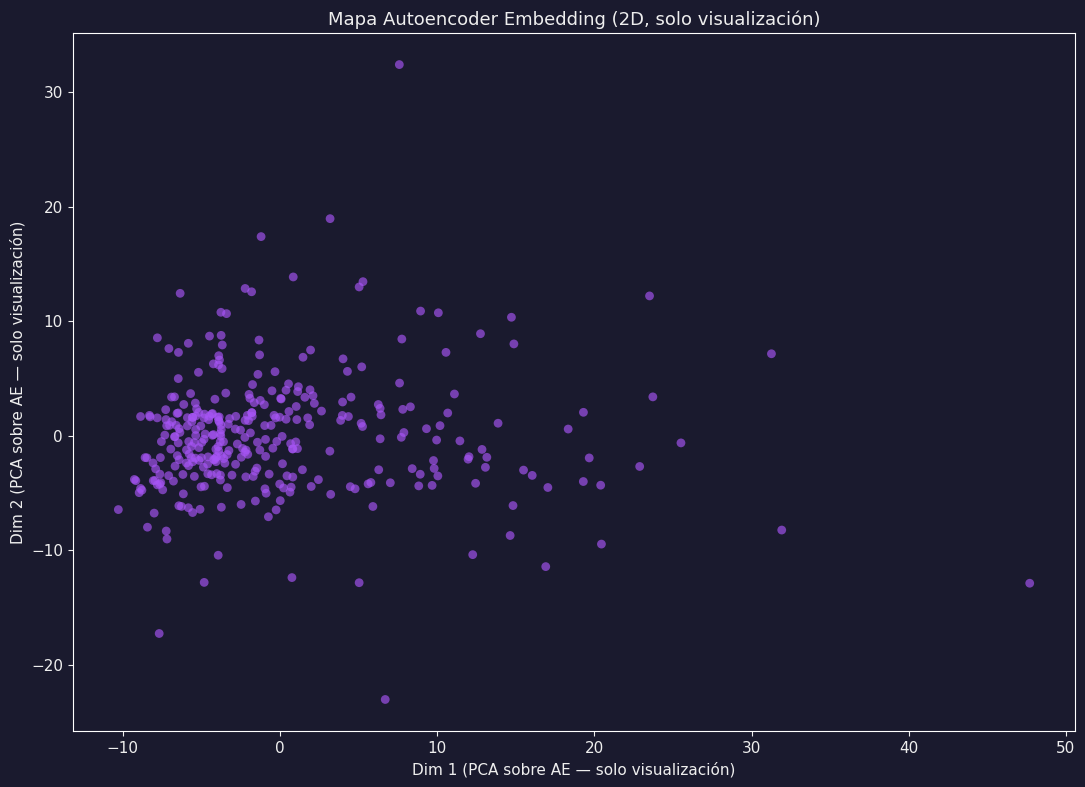

⚠️  Las coordenadas 2D son SOLO de visualización. El embedding real son las columnas AE_VEC_*.


In [14]:
# ── Gráficos del autoencoder ──────────────────────────────────────────────────

# Gráfico 1: Pérdida
fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
ax.plot(history.history["loss"],     color=PAL[0], lw=2, label="Train")
ax.plot(history.history["val_loss"], color=PAL[1], lw=2, label="Val", ls="--")
ax.set_xlabel("Época", color=TXT); ax.set_ylabel("MSE", color=TXT)
ax.set_title("Autoencoder — Pérdida de entrenamiento y validación", color=TXT)
ax.legend(facecolor=BG, labelcolor=TXT); ax.tick_params(colors=TXT)
plt.tight_layout(); plt.savefig("ae_loss.png", dpi=120, bbox_inches="tight"); plt.show()

# Gráfico 2: Distribución error de reconstrucción
fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
ax.hist(recon_errors, bins=30, color=ACC, alpha=0.85)
ax.axvline(mean_error, color="yellow", ls="--", lw=1.5, label=f"Media: {mean_error:.4f}")
ax.set_xlabel("Error de reconstrucción (MSE)", color=TXT); ax.set_ylabel("N jugadores", color=TXT)
ax.set_title("Distribución del error de reconstrucción — Autoencoder", color=TXT)
ax.legend(facecolor=BG, labelcolor=TXT); ax.tick_params(colors=TXT)
plt.tight_layout(); plt.savefig("ae_recon_error.png", dpi=120, bbox_inches="tight"); plt.show()

# Gráfico 3: Mapa 2D (PCA sobre el embedding del AE — solo visualización)
if AE_DIM >= 2:
    pca_vis  = PCA(n_components=2, random_state=CONFIG["RANDOM_STATE"])
    X_ae_2d  = pca_vis.fit_transform(X_ae)
else:
    X_ae_2d  = np.column_stack([X_ae[:, 0], np.zeros(len(X_ae))])

fig, ax = plt.subplots(figsize=(11, 8), facecolor=BG)
ax.scatter(X_ae_2d[:, 0], X_ae_2d[:, 1], c=PAL[3], s=40, alpha=0.65, edgecolors="none")
ax.set_xlabel("Dim 1 (PCA sobre AE — solo visualización)", color=TXT)
ax.set_ylabel("Dim 2 (PCA sobre AE — solo visualización)", color=TXT)
ax.set_title("Mapa Autoencoder Embedding (2D, solo visualización)", color=TXT)
ax.tick_params(colors=TXT)
plt.tight_layout(); plt.savefig("ae_map2d.png", dpi=120, bbox_inches="tight"); plt.show()
print("⚠️  Las coordenadas 2D son SOLO de visualización. El embedding real son las columnas AE_VEC_*.")

---
## 9. Embedding de Contexto (Word2Vec)

Cada combinación `TARGET_GAME_ID + TEAM` se trata como una **frase**;
cada `PLAYER_ID` como una **palabra**.

La proximidad refleja **coexistencia en partidos**, NO similitud estadística.

> Jugadores del mismo equipo y rotación tienden a aparecer cercanos.
> Esto puede capturar alineaciones y patrones de uso, pero no implica
> equivalencia de estilo ni causalidad.

In [15]:
def build_context_sequences(df: pd.DataFrame, col_map: dict) -> tuple:
    """
    Construye secuencias de jugadores por partido/equipo para Word2Vec.

    Prioridad:
    1. TARGET_GAME_ID + TEAM  →  jugadores del mismo equipo en el mismo partido
    2. TARGET_GAME_ID         →  todos los jugadores del partido
    3. Secuencias temporales  →  ventanas por fecha (fallback)

    El token es str(PLAYER_ID) para garantizar estabilidad.
    Retorna (sequences, method_used)
    """
    id_col   = col_map.get("player_id") or col_map.get("player_name")
    game_col = col_map.get("game_id")
    team_col = col_map.get("team")
    date_col = col_map.get("date")

    if id_col is None:
        raise ValueError("Se requiere columna de ID de jugador")

    token_col = id_col  # usar PLAYER_ID como token

    # Opción 1: mismo equipo + mismo partido (óptima)
    if game_col and team_col and game_col in df.columns and team_col in df.columns:
        groups = df.groupby([game_col, team_col])[token_col].apply(
            lambda x: [str(v) for v in x.dropna().unique()]
        )
        seqs = [s for s in groups if len(s) >= 2]
        if seqs:
            print(f"📋 Contexto: GAME_ID + TEAM (opción 1 — óptima)")
            print(f"   Cada frase = jugadores del mismo equipo en el mismo partido")
            return seqs, "game_team"

    # Opción 2: mismo partido
    if game_col and game_col in df.columns:
        groups = df.groupby(game_col)[token_col].apply(
            lambda x: [str(v) for v in x.dropna().unique()]
        )
        seqs = [s for s in groups if len(s) >= 2]
        if seqs:
            print(f"📋 Contexto: GAME_ID (opción 2)")
            return seqs, "game"

    # Opción 3: ventanas temporales
    if date_col and date_col in df.columns:
        df_s = df.sort_values(date_col)
        all_tokens = [str(v) for v in df_s[token_col].dropna()]
        w = CONTEXT_CONFIG["window"] * 2 + 1
        seqs = [all_tokens[i:i+w] for i in range(0, len(all_tokens) - w + 1, w // 2)]
        print(f"📋 Contexto: secuencias temporales (opción 3 — fallback)")
        return seqs, "temporal"

    raise RuntimeError("No fue posible construir secuencias de contexto")


sequences, context_method = build_context_sequences(df_raw, COL)

avg_len = np.mean([len(s) for s in sequences])
print(f"\n   Contextos construidos:  {len(sequences):,}")
print(f"   Longitud media:         {avg_len:.1f} jugadores/contexto")

📋 Contexto: GAME_ID + TEAM (opción 1 — óptima)
   Cada frase = jugadores del mismo equipo en el mismo partido

   Contextos construidos:  304
   Longitud media:         10.3 jugadores/contexto


In [16]:
# ── Entrenamiento Word2Vec ─────────────────────────────────────────────────────
w2v = Word2Vec(
    sentences=sequences,
    vector_size=CONTEXT_CONFIG["vector_size"],
    window=CONTEXT_CONFIG["window"],
    min_count=CONTEXT_CONFIG["min_count"],
    sg=CONTEXT_CONFIG["sg"],
    negative=CONTEXT_CONFIG["negative"],
    epochs=CONTEXT_CONFIG["epochs"],
    seed=CONTEXT_CONFIG["seed"],
    workers=1,      # workers=1 garantiza reproducibilidad
)

vocab_tokens = set(w2v.wv.key_to_index.keys())
print(f"\n✅ Word2Vec entrenado")
print(f"   Jugadores en vocabulario:  {len(vocab_tokens)}")

# Jugadores excluidos por min_count
all_tokens_seen = set(t for s in sequences for t in s)
excluded_tokens = all_tokens_seen - vocab_tokens
print(f"   Excluidos (min_count={CONTEXT_CONFIG['min_count']}): {len(excluded_tokens)}")

# ── Mapa token → nombre ────────────────────────────────────────────────────────
id_col_v   = COL.get("player_id")
name_col_v = COL.get("player_name")

token_to_name = {}
if id_col_v and name_col_v and id_col_v in df_raw.columns and name_col_v in df_raw.columns:
    token_to_name = {
        str(k): v
        for k, v in df_raw.drop_duplicates(subset=[id_col_v])
                          .set_index(id_col_v)[name_col_v].to_dict().items()
    }

# ── DataFrame context embeddings ──────────────────────────────────────────────
ctx_records = []
for token in vocab_tokens:
    vec = w2v.wv[token]
    row = {}
    row[id_col_v   or "PLAYER_ID"]    = token
    row[name_col_v or "PLAYER_NAME"]  = token_to_name.get(token, token)
    for i, v in enumerate(vec):
        row[f"CTX_VEC_{i+1:02d}"] = v
    ctx_records.append(row)

context_embeddings_df = pd.DataFrame(ctx_records)
print(f"\n✅ context_embeddings_df: {context_embeddings_df.shape}")
context_embeddings_df.head(3)


✅ Word2Vec entrenado
   Jugadores en vocabulario:  421
   Excluidos (min_count=2): 31

✅ context_embeddings_df: (421, 12)


,PLAYER_ID,PLAYER_NAME,CTX_VEC_01,CTX_VEC_02,CTX_VEC_03,CTX_VEC_04,CTX_VEC_05,CTX_VEC_06,CTX_VEC_07,CTX_VEC_08,CTX_VEC_09,CTX_VEC_10
0,1641711,Gradey Dick,-0.967648,-0.387081,-0.359567,0.957348,3.526167,-1.205576,-0.616417,-0.371156,-1.734661,1.143919
1,1641998,Trey Jemison III,0.242390,0.595284,1.332244,0.951106,0.754864,-1.772895,-0.711964,-1.556966,-2.401408,0.049613
2,1631169,Josh Minott,2.063176,0.811584,0.997524,-1.459395,1.816300,0.302498,-0.632785,-1.699909,-0.687972,-0.369039


---
## 10. Jugadores Similares

In [17]:
def find_similar_players(player_name: str,
                        embeddings_df: pd.DataFrame,
                        vector_prefix: str,
                        top_n: int = 10) -> pd.DataFrame:
    """
    Encuentra los jugadores más similares usando similitud coseno.

    Parámetros
    ----------
    player_name    : búsqueda parcial sin distinción de mayúsculas
    embeddings_df  : DataFrame con columnas <vector_prefix>*
    vector_prefix  : 'PCA_VEC_', 'AE_VEC_' o 'CTX_VEC_'
    top_n          : número de vecinos a retornar

    Salida
    ------
    DataFrame con columnas RANK, PLAYER_ID, PLAYER_NAME, SIMILARITY
    """
    name_col_e = COL.get("player_name") or COL.get("player_id")
    id_col_e   = COL.get("player_id")   or COL.get("player_name")
    vec_cols   = [c for c in embeddings_df.columns if c.startswith(vector_prefix)]

    if not vec_cols:
        print(f"⚠️  No se encontraron columnas '{vector_prefix}*'"); return pd.DataFrame()

    # Columna de búsqueda
    search_col = None
    for sc in [name_col_e, id_col_e]:
        if sc and sc in embeddings_df.columns:
            search_col = sc; break
    if search_col is None:
        print("⚠️  No se encontró columna de nombre/ID en el embedding"); return pd.DataFrame()

    mask = embeddings_df[search_col].astype(str).str.contains(
        player_name, case=False, na=False
    )
    if not mask.any():
        print(f"⚠️  '{player_name}' no encontrado en {vector_prefix} embedding")
        return pd.DataFrame()

    query_row  = embeddings_df[mask].iloc[0]
    query_name = query_row[search_col]
    query_vec  = query_row[vec_cols].values.astype(float)

    X_emb = embeddings_df[vec_cols].values.astype(float)
    sims  = 1 - pairwise_distances(query_vec.reshape(1,-1), X_emb, metric="cosine")[0]

    result = embeddings_df.copy()
    result["SIMILARITY"] = sims
    result = result[result[search_col].astype(str) != str(query_name)]
    result = result.nlargest(top_n, "SIMILARITY").reset_index(drop=True)
    result.insert(0, "RANK", range(1, len(result) + 1))

    keep = ["RANK"]
    if id_col_e in result.columns:   keep.append(id_col_e)
    if name_col_e in result.columns and name_col_e != id_col_e: keep.append(name_col_e)
    keep.append("SIMILARITY")
    return result[[c for c in keep if c in result.columns]]


print("✅ Función find_similar_players definida")

✅ Función find_similar_players definida


In [18]:
# ── Selección automática de jugadores de ejemplo ──────────────────────────────
def pick_example_players(profiles_df, name_col, n=5):
    """
    Intenta encontrar jugadores conocidos; completa con uno por cluster PCA.
    Solo usa jugadores realmente presentes en el dataset.
    """
    KNOWN = [
        "Stephen Curry", "Curry", "LeBron", "LeBron James",
        "Nikola Jokic", "Jokic", "Giannis", "Trae Young",
        "Damian Lillard", "Lillard", "Kevin Durant", "Durant",
        "Rudy Gobert", "Gobert", "Jayson Tatum", "Tatum",
        "Joel Embiid", "Embiid", "Devin Booker", "Booker",
    ]
    found = []
    if name_col in profiles_df.columns:
        all_names = profiles_df[name_col].dropna().tolist()
        for known in KNOWN:
            for pname in all_names:
                if known.lower() in str(pname).lower() and pname not in found:
                    found.append(pname); break
            if len(found) >= n: break

    # Completar con un representante por cluster PCA
    if len(found) < n and name_col in profiles_df.columns:
        k_tmp = min(n, len(profiles_df))
        km_tmp = KMeans(n_clusters=k_tmp,
                        random_state=CONFIG["RANDOM_STATE"], n_init=10).fit(X_player_scaled)
        all_names_list = profiles_df[name_col].tolist()
        for cl in range(k_tmp):
            idx = [i for i, l in enumerate(km_tmp.labels_) if l == cl]
            if idx and all_names_list[idx[0]] not in found:
                found.append(all_names_list[idx[0]])
            if len(found) >= n: break
    return found[:n]


EXAMPLE_PLAYERS = pick_example_players(
    player_profiles_df, NAME_COL or "PLAYER_NAME", n=5
)
print(f"Jugadores de ejemplo: {EXAMPLE_PLAYERS}")

Jugadores de ejemplo: ['LeBron James', 'Kevin Durant', 'Rudy Gobert', 'Jonas Valančiūnas', 'Russell Westbrook']


In [19]:
# ── Top-5 vecinos para cada jugador de ejemplo ────────────────────────────────
for pname in EXAMPLE_PLAYERS:
    print(f"\n{'='*60}")
    print(f"  JUGADOR: {pname}")
    print(f"{'='*60}")
    for emb_df, prefix, label in [
        (pca_embeddings_df,         "PCA_VEC_", "PCA"),
        (autoencoder_embeddings_df, "AE_VEC_",  "Autoencoder"),
        (context_embeddings_df,     "CTX_VEC_", "Contexto"),
    ]:
        print(f"\n  [{label}]")
        res = find_similar_players(pname, emb_df, prefix, top_n=5)
        if not res.empty:
            print(res.to_string(index=False))
        else:
            print(f"  Sin resultados para '{pname}' en {label}")


  JUGADOR: LeBron James

  [PCA]
 RANK  PLAYER_ID     PLAYER_NAME  SIMILARITY
    1    1630581     Josh Giddey    0.953100
    2    1630595 Cade Cunningham    0.875875
    3    1630559   Austin Reaves    0.845343
    4    1627759    Jaylen Brown    0.833719
    5    1628368    De'Aaron Fox    0.827851

  [Autoencoder]
 RANK  PLAYER_ID     PLAYER_NAME  SIMILARITY
    1    1630581     Josh Giddey    0.982918
    2    1629628      RJ Barrett    0.923010
    3    1630595 Cade Cunningham    0.919768
    4     201950    Jrue Holiday    0.917448
    5    1629614 Andrew Nembhard    0.914729

  [Contexto]
 RANK PLAYER_ID       PLAYER_NAME  SIMILARITY
    1    203935      Marcus Smart    0.993681
    2   1628379      Luke Kennard    0.993577
    3   1628467       Maxi Kleber    0.982663
    4   1629020 Jarred Vanderbilt    0.970217
    5   1629028     Deandre Ayton    0.964411

  JUGADOR: Kevin Durant

  [PCA]
 RANK  PLAYER_ID     PLAYER_NAME  SIMILARITY
    1    1630162 Anthony Edwards    0.95

---
## 11. Visualizaciones Comparativas

Tres mapas 2D usando PCA sobre el embedding de cada método (solo visualización).

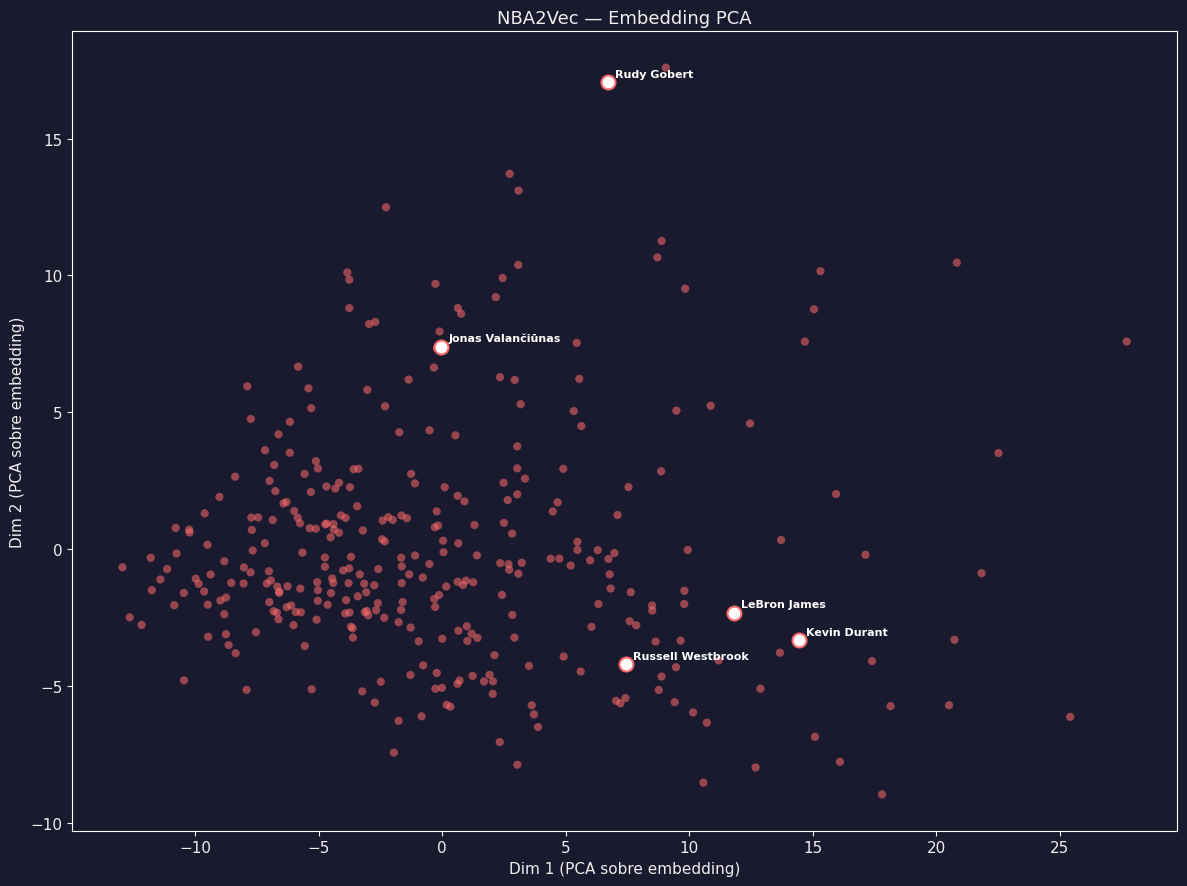

   Jugadores destacados: 5


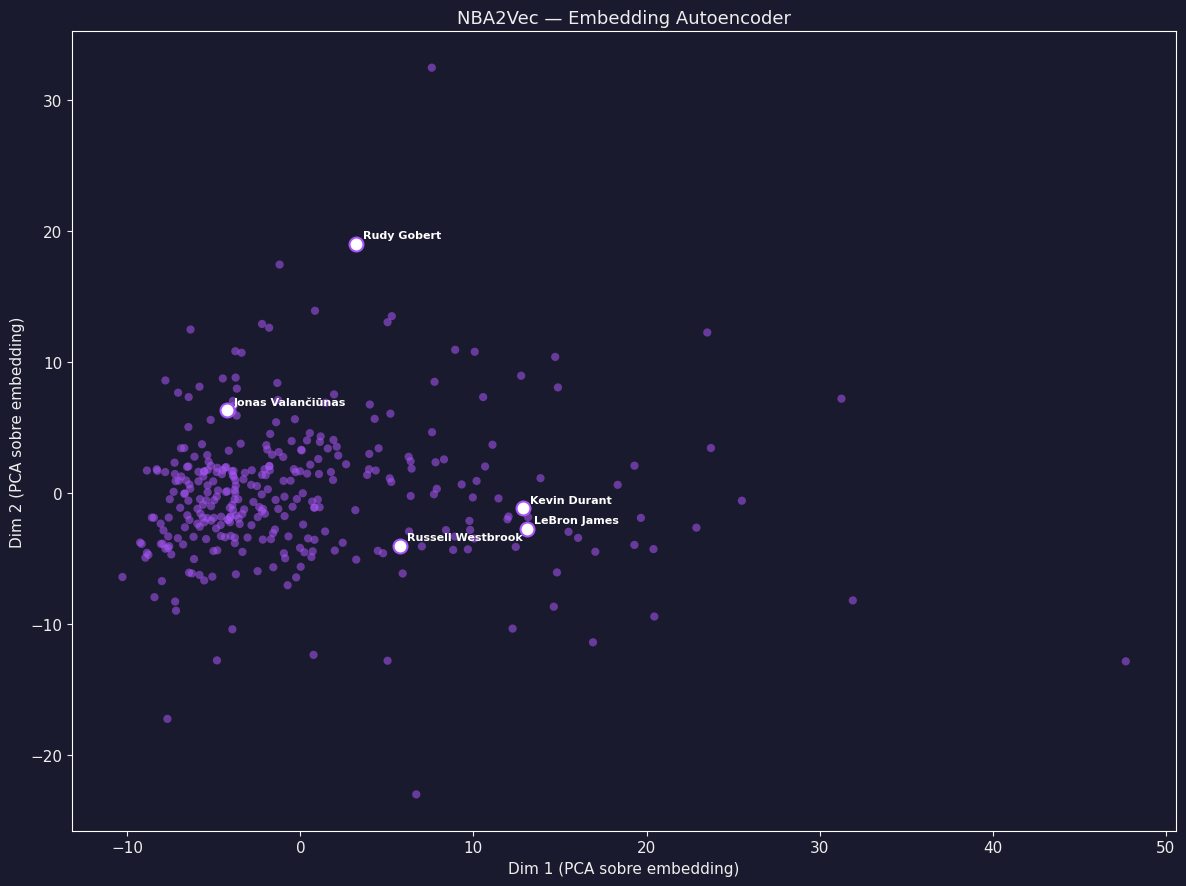

   Jugadores destacados: 5


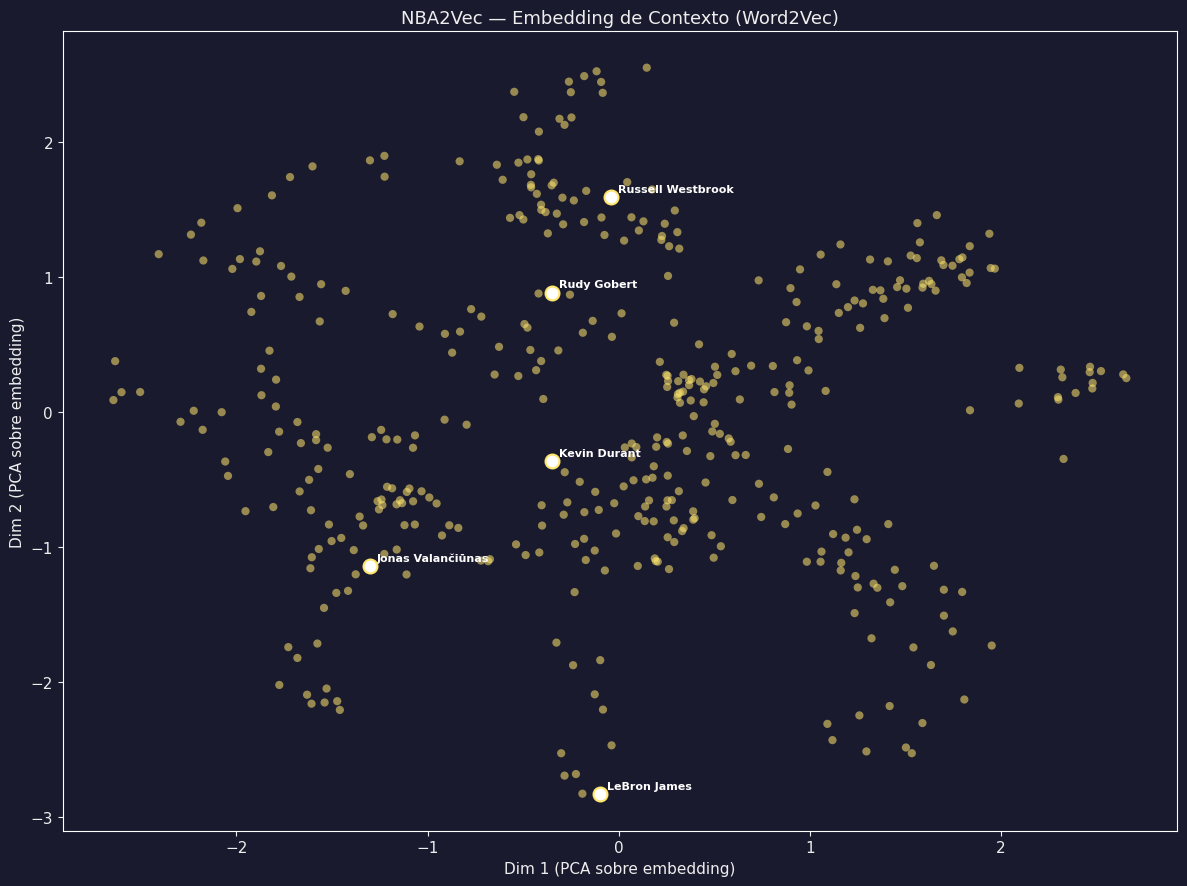

   Jugadores destacados: 5


In [20]:
def embed_to_2d(X, seed):
    n = min(2, X.shape[1], X.shape[0] - 1)
    if n < 2:
        return np.column_stack([X[:, 0], np.zeros(len(X))])
    return PCA(n_components=2, random_state=seed).fit_transform(X)


def plot_map(coords, names, highlights, title, color, fname):
    fig, ax = plt.subplots(figsize=(12, 9), facecolor=BG)
    ax.scatter(coords[:, 0], coords[:, 1],
               c=color, s=35, alpha=0.55, edgecolors="none")
    labeled = 0
    for i, name in enumerate(names):
        if any(h.lower() in str(name).lower() for h in highlights):
            ax.scatter(coords[i, 0], coords[i, 1], c="white", s=100,
                       edgecolors=color, linewidths=1.5, zorder=5)
            ax.annotate(str(name), (coords[i, 0], coords[i, 1]),
                        fontsize=8, color="white", fontweight="bold",
                        xytext=(5, 4), textcoords="offset points")
            labeled += 1
    ax.set_xlabel("Dim 1 (PCA sobre embedding)", color=TXT)
    ax.set_ylabel("Dim 2 (PCA sobre embedding)", color=TXT)
    ax.set_title(title, color=TXT); ax.tick_params(colors=TXT)
    plt.tight_layout()
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"   Jugadores destacados: {labeled}")


seed_v   = CONFIG["RANDOM_STATE"]
name_c   = NAME_COL or ID_COL or "PLAYER_NAME"
highlights = EXAMPLE_PLAYERS

pca_vec_cols = [c for c in pca_embeddings_df.columns if c.startswith("PCA_VEC_")]
ae_vec_cols  = [c for c in autoencoder_embeddings_df.columns if c.startswith("AE_VEC_")]
ctx_vec_cols = [c for c in context_embeddings_df.columns if c.startswith("CTX_VEC_")]

# Mapa PCA
coords_pca = embed_to_2d(pca_embeddings_df[pca_vec_cols].values, seed_v)
pca_names  = pca_embeddings_df.get(name_c,
             pd.Series(range(len(pca_embeddings_df)))).tolist()
plot_map(coords_pca, pca_names, highlights,
         "NBA2Vec — Embedding PCA", PAL[0], "viz_pca.png")

# Mapa Autoencoder
coords_ae = embed_to_2d(autoencoder_embeddings_df[ae_vec_cols].values, seed_v)
ae_names  = autoencoder_embeddings_df.get(name_c,
            pd.Series(range(len(autoencoder_embeddings_df)))).tolist()
plot_map(coords_ae, ae_names, highlights,
         "NBA2Vec — Embedding Autoencoder", PAL[3], "viz_ae.png")

# Mapa Contexto
coords_ctx = embed_to_2d(context_embeddings_df[ctx_vec_cols].values, seed_v)
ctx_names  = context_embeddings_df.get(name_c,
             pd.Series(range(len(context_embeddings_df)))).tolist()
plot_map(coords_ctx, ctx_names, highlights,
         "NBA2Vec — Embedding de Contexto (Word2Vec)", PAL[2], "viz_ctx.png")

---
## 12. Clustering Resumido

K-Means independiente sobre cada embedding.

In [21]:
def cluster_summary(embeddings_df, vec_prefix, label, n_clusters, name_col, seed):
    """
    Aplica K-Means y muestra: tamaño de clusters y 3 jugadores más representativos.
    Ajusta K si hay pocos jugadores.
    """
    vec_cols = [c for c in embeddings_df.columns if c.startswith(vec_prefix)]
    if not vec_cols:
        print(f"⚠️  Sin columnas {vec_prefix}*"); return

    X = embeddings_df[vec_cols].values
    k = min(n_clusters, len(embeddings_df) - 1)
    if k < 2:
        print(f"⚠️  Insuficientes jugadores ({len(embeddings_df)})"); return

    km     = KMeans(n_clusters=k, random_state=seed, n_init=10)
    labels = km.fit_predict(X)
    sil    = silhouette_score(X, labels) if k > 1 else float("nan")

    print(f"\n{'='*55}")
    print(f"  CLUSTERING — {label}  (K={k}, Silhouette={sil:.3f})")
    print(f"{'='*55}")
    for cl in range(k):
        mask  = labels == cl
        X_cl  = X[mask]
        dists = np.linalg.norm(X_cl - km.cluster_centers_[cl], axis=1)
        top3  = np.argsort(dists)[:3]
        if name_col and name_col in embeddings_df.columns:
            top3_n = embeddings_df[name_col].values[mask][top3].tolist()
        else:
            top3_n = [f"Player_{i}" for i in top3]
        print(f"  C{cl}: {mask.sum():3d} jugadores │ Más representativos: {top3_n}")


name_c2 = NAME_COL or ID_COL or "PLAYER_NAME"
k_cfg   = CONFIG["N_CLUSTERS"]
seed_v  = CONFIG["RANDOM_STATE"]

cluster_summary(pca_embeddings_df,         "PCA_VEC_", "PCA",         k_cfg, name_c2, seed_v)
cluster_summary(autoencoder_embeddings_df, "AE_VEC_",  "Autoencoder", k_cfg, name_c2, seed_v)
cluster_summary(context_embeddings_df,     "CTX_VEC_", "Contexto",    k_cfg, name_c2, seed_v)


  CLUSTERING — PCA  (K=8, Silhouette=0.169)
  C0:   3 jugadores │ Más representativos: ['Scoot Henderson', 'Ty Jerome', 'Scotty Pippen Jr.']
  C1:  43 jugadores │ Más representativos: ['Ace Bailey', 'Sandro Mamukelashvili', 'John Collins']
  C2:  95 jugadores │ Más representativos: ['Caleb Martin', 'Kobe Sanders', 'Noah Penda']
  C3:  39 jugadores │ Más representativos: ['Nickeil Alexander-Walker', 'Jalen Brunson', 'Immanuel Quickley']
  C4:  26 jugadores │ Más representativos: ['Mark Williams', 'Marvin Bagley III', 'Deandre Ayton']
  C5:  49 jugadores │ Más representativos: ['Tre Johnson', 'Jaylen Wells', 'Ayo Dosunmu']
  C6:  14 jugadores │ Más representativos: ['Paolo Banchero', 'Jaylen Brown', 'Jalen Johnson']
  C7:  59 jugadores │ Más representativos: ['Amir Coffey', 'Justin Edwards', 'Jase Richardson']

  CLUSTERING — Autoencoder  (K=8, Silhouette=0.167)
  C0:  54 jugadores │ Más representativos: ['Mohamed Diawara', 'Amir Coffey', 'Kelly Olynyk']
  C1:  21 jugadores │ Más repres

---
## 13. Comparación de Métodos

In [22]:
embedding_comparison_df = pd.DataFrame([
    {
        "METHOD":              "PCA",
        "INPUT":               "Features pre-partido ya agregadas en dataset_nba",
        "EMBEDDING_DIM":       len([c for c in pca_embeddings_df.columns if c.startswith("PCA_VEC_")]),
        "N_PLAYERS":           len(pca_embeddings_df),
        "INTERPRETABILITY":    "Alta — loadings directamente legibles",
        "NON_LINEAR":          "No",
        "USES_CONTEXT":        "No",
        "MAIN_LIMITATION":     "Lineal; no captura interacciones complejas",
    },
    {
        "METHOD":              "Autoencoder",
        "INPUT":               "Features pre-partido ya agregadas en dataset_nba",
        "EMBEDDING_DIM":       AE_DIM,
        "N_PLAYERS":           len(autoencoder_embeddings_df),
        "INTERPRETABILITY":    "Baja — espacio latente no interpretable directamente",
        "NON_LINEAR":          "Sí",
        "USES_CONTEXT":        "No",
        "MAIN_LIMITATION":     "Requiere suficientes datos; sensible a arquitectura",
    },
    {
        "METHOD":              "Word2Vec (Contexto)",
        "INPUT":               f"Coexistencia en partidos ({context_method})",
        "EMBEDDING_DIM":       CONTEXT_CONFIG["vector_size"],
        "N_PLAYERS":           len(context_embeddings_df),
        "INTERPRETABILITY":    "Media — refleja patrones de coexistencia",
        "NON_LINEAR":          "Sí",
        "USES_CONTEXT":        "Sí",
        "MAIN_LIMITATION":     "No usa estadísticas; depende de calidad de agrupaciones por partido",
    },
])

print("\n📊 COMPARACIÓN DE MÉTODOS")
print(embedding_comparison_df.to_string(index=False))


📊 COMPARACIÓN DE MÉTODOS
             METHOD                                            INPUT  EMBEDDING_DIM  N_PLAYERS                                     INTERPRETABILITY NON_LINEAR USES_CONTEXT                                                     MAIN_LIMITATION
                PCA Features pre-partido ya agregadas en dataset_nba             10        328                Alta — loadings directamente legibles         No           No                          Lineal; no captura interacciones complejas
        Autoencoder Features pre-partido ya agregadas en dataset_nba             10        328 Baja — espacio latente no interpretable directamente         Sí           No                 Requiere suficientes datos; sensible a arquitectura
Word2Vec (Contexto)             Coexistencia en partidos (game_team)             10        421             Media — refleja patrones de coexistencia         Sí           Sí No usa estadísticas; depende de calidad de agrupaciones por partido


---
## 14. Conclusiones

In [25]:
print("""
╔══════════════════════════════════════════════════════════════╗
║          CONCLUSIONES — NBA2Vec Comparación de Métodos      ║
╚══════════════════════════════════════════════════════════════╝

CONTEXTO: el dataset_nba ya contiene features pre-partido agregadas
(promedios de temporada, ventanas L10/L20, tendencias, etc.).
No se recalculó historia; el perfil de cada jugador se obtuvo
promediando sus filas disponibles en el dataset.

1. ¿QUÉ JUGADORES APARECEN CERCANOS CON PCA?
   Jugadores con perfiles estadísticos pre-partido similares:
   mismo volumen de triples, minutos, eficiencia y tendencias.
   La proximidad es lineal y directamente interpretable via loadings.

2. ¿QUÉ JUGADORES APARECEN CERCANOS CON EL AUTOENCODER?
   Jugadores con patrones similares capturados de forma no lineal.
   Puede identificar combinaciones de variables que PCA no separa.
   Los vecinos pueden diferir del PCA si existen relaciones no lineales.

3. ¿QUÉ JUGADORES APARECEN CERCANOS CON EL EMBEDDING DE CONTEXTO?
   Jugadores que comparten frecuentemente el mismo equipo y partido.
   Compañeros de rotación pueden quedar cercanos independientemente
   de sus estadísticas individuales.

4. ¿QUÉ DIFERENCIAS EXISTEN ENTRE LOS TRES RESULTADOS?
   PCA y AE: similitud estadística (misma entrada).
   Contexto:  similitud por coexistencia (entrada diferente).
   PCA y AE pueden divergir si hay patrones no lineales relevantes.

5. ¿QUÉ REPRESENTACIÓN ES MÁS INTERPRETABLE?
   PCA: los loadings conectan directamente cada componente
   con variables concretas del dataset_nba.

6. ¿QUÉ REPRESENTACIÓN CAPTURA RELACIONES NO LINEALES?
   Autoencoder y Word2Vec (contexto).

7. ¿QUÉ REPRESENTACIÓN CAPTURA COEXISTENCIA?
   Embedding de contexto (Word2Vec).

8. ¿CUÁL CONSERVAR PARA EVALUACIÓN PREDICTIVA FUTURA?
   PCA:     por interpretabilidad y control riguroso de fuga.
   AE:      si se valida que captura señal adicional útil.
   Contexto: como feature complementaria de coexistencia.
   ⚠️  Esta decisión requiere validación predictiva posterior.
   ⚠️  Ningún embedding usa TARGET_FG3M ni NEXT_GAME_* como entrada.
""")


╔══════════════════════════════════════════════════════════════╗
║          CONCLUSIONES — NBA2Vec Comparación de Métodos      ║
╚══════════════════════════════════════════════════════════════╝

CONTEXTO: el dataset_nba ya contiene features pre-partido agregadas
(promedios de temporada, ventanas L10/L20, tendencias, etc.).
No se recalculó historia; el perfil de cada jugador se obtuvo
promediando sus filas disponibles en el dataset.

1. ¿QUÉ JUGADORES APARECEN CERCANOS CON PCA?
   Jugadores con perfiles estadísticos pre-partido similares:
   mismo volumen de triples, minutos, eficiencia y tendencias.
   La proximidad es lineal y directamente interpretable via loadings.

2. ¿QUÉ JUGADORES APARECEN CERCANOS CON EL AUTOENCODER?
   Jugadores con patrones similares capturados de forma no lineal.
   Puede identificar combinaciones de variables que PCA no separa.
   Los vecinos pueden diferir del PCA si existen relaciones no lineales.

3. ¿QUÉ JUGADORES APARECEN CERCANOS CON EL EMBEDDING DE C

---
## Dataframes Finales

In [24]:
# @title
print("✅ Dataframes disponibles en memoria:")
for name, df in [
    ("player_profiles_df",        player_profiles_df),
    ("pca_embeddings_df",         pca_embeddings_df),
    ("autoencoder_embeddings_df", autoencoder_embeddings_df),
    ("context_embeddings_df",     context_embeddings_df),
    ("embedding_comparison_df",   embedding_comparison_df),
]:
    print(f"   {name:<35} {df.shape[0]:>4} filas × {df.shape[1]:>3} cols")

# ─────────────────────────────────────────────────────────────────────────────
# EXPORTACIÓN OPCIONAL — descomenta para guardar en GCS
# ─────────────────────────────────────────────────────────────────────────────
# import gcsfs
# OUTPUT_BASE = f"gs://{CONFIG['GCS_BUCKET']}/nba2vec_outputs"
# fs = gcsfs.GCSFileSystem()
# for name, df in [
#     ("player_profiles_df",        player_profiles_df),
#     ("pca_embeddings_df",         pca_embeddings_df),
#     ("autoencoder_embeddings_df", autoencoder_embeddings_df),
#     ("context_embeddings_df",     context_embeddings_df),
#     ("embedding_comparison_df",   embedding_comparison_df),
# ]:
#     path = f"{OUTPUT_BASE}/{name}.csv"
#     with fs.open(path, "w") as f:
#         df.to_csv(f, index=False)
#     print(f"   Guardado: {path}")

print("\n   (Exportación desactivada. Descomenta el bloque anterior para guardar.)")

✅ Dataframes disponibles en memoria:
   player_profiles_df                   328 filas × 170 cols
   pca_embeddings_df                    328 filas ×  13 cols
   autoencoder_embeddings_df            328 filas ×  13 cols
   context_embeddings_df                421 filas ×  12 cols
   embedding_comparison_df                3 filas ×   8 cols

   (Exportación desactivada. Descomenta el bloque anterior para guardar.)
